In [2]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
%matplotlib inline


In [3]:
def clustering_score(original_adata, score_value = 'bic', clustering_algorithm='leiden', dim_reduction = 'pca', min_res=0.1, max_res=2.0, step=0.1, plot=True):
    #calinski_harabasz
    import numpy as nu
    import scanpy as sc
    import numpy as nu
    from sklearn.metrics import calinski_harabasz_score

    sc.settings.verbosity = 0

    if dim_reduction == 'pca':
        dim_reduction = 'X_pca'
    elif dim_reduction == 'umap':
        dim_reduction = 'X_umap'
    else:
        print('please choose pca or umap as dimensionality reduction')
        exit

    res = list(nu.arange(min_res,max_res,step))
    score = []
    n_clus = []

    for r in res:
        index = res.index(r)
        adata = original_adata.copy()
        string_r = str(r)
        clustering_name = '%s_res%s' %(clustering_algorithm,string_r)
        print('Clustering by using the resolution %.2f, step %i of %i' %(r,index+1,len(res)))
        if clustering_algorithm == 'leiden':
            sc.tl.leiden(adata, key_added="%s_res%s" %(clustering_algorithm,string_r), resolution=r)
        elif clustering_algorithm == 'louvain':
            sc.tl.louvain(adata, key_added="%s_res%s" %(clustering_algorithm,string_r), resolution=r)
        else:
            print('please choose louvain or leiden as clustering_algorithm')
            exit
        if score_value == 'bic':
            score_name = 'BIC score'
            n_points = len(adata.obs[clustering_name])
            n_clusters = len(set(adata.obs[clustering_name]))
            n_dimensions = adata.obsm[dim_reduction].shape[1]

            n_parameters = (n_clusters - 1) + (n_dimensions * n_clusters) + 1

            loglikelihood=0
            for cluster_id in set(adata.obs[clustering_name]):
                cluster_mask = (adata.obs[clustering_name] == cluster_id)
                X_cluster = adata.obsm[dim_reduction][cluster_mask]

                n_points_cluster = len(X_cluster)
                centroid = nu.mean(X_cluster, axis=0)
                variance = nu.sum((X_cluster - centroid) ** 2) / (len(X_cluster) - 1)
                loglikelihood += \
                  n_points_cluster * nu.log(n_points_cluster) \
                  - n_points_cluster * nu.log(n_points) \
                  - n_points_cluster * n_dimensions / 2 * nu.log(2 * nu.pi * variance) \
                  - (n_points_cluster - 1) / 2

            bic = loglikelihood - (n_parameters / 2) * nu.log(n_points)
            bic = -2*bic
            score.append(bic)
            n_clus.append(n_clusters)

            del adata.obs[clustering_name]
        
        elif score_value == 'calinski':
            score_name = 'Calinski-Harabasz score'
            n_clusters = len(set(adata.obs[clustering_name]))
            n_clus.append(n_clusters)
            score.append(-1*calinski_harabasz_score(adata.obsm[dim_reduction], adata.obs[clustering_name]))
            

    df = pd.DataFrame()
    df[score_name] = score
    df['resolution'] = res
    df['n_clus'] = n_clus

    if plot==True:
        df.plot(x='resolution',y=score_name)
    print('\n')

    return df, res[nu.argmin(score)]

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_header()
sc.settings.set_figure_params(dpi=200, facecolor='white')

In [4]:
##Load the dataset
adata = sc.read_10x_mtx("/home/ssarnataro/Work/3kPBMC_data/filtered_gene_bc_matrices/hg19/", var_names = 'gene_symbols', cache = True)


... reading from cache file cache/home-ssarnataro-Work-3kPBMC_data-filtered_gene_bc_matrices-hg19-matrix.h5ad


In [5]:
adata.var_names_make_unique()

#### Preprocessing

normalizing counts per cell
    finished (0:00:00)


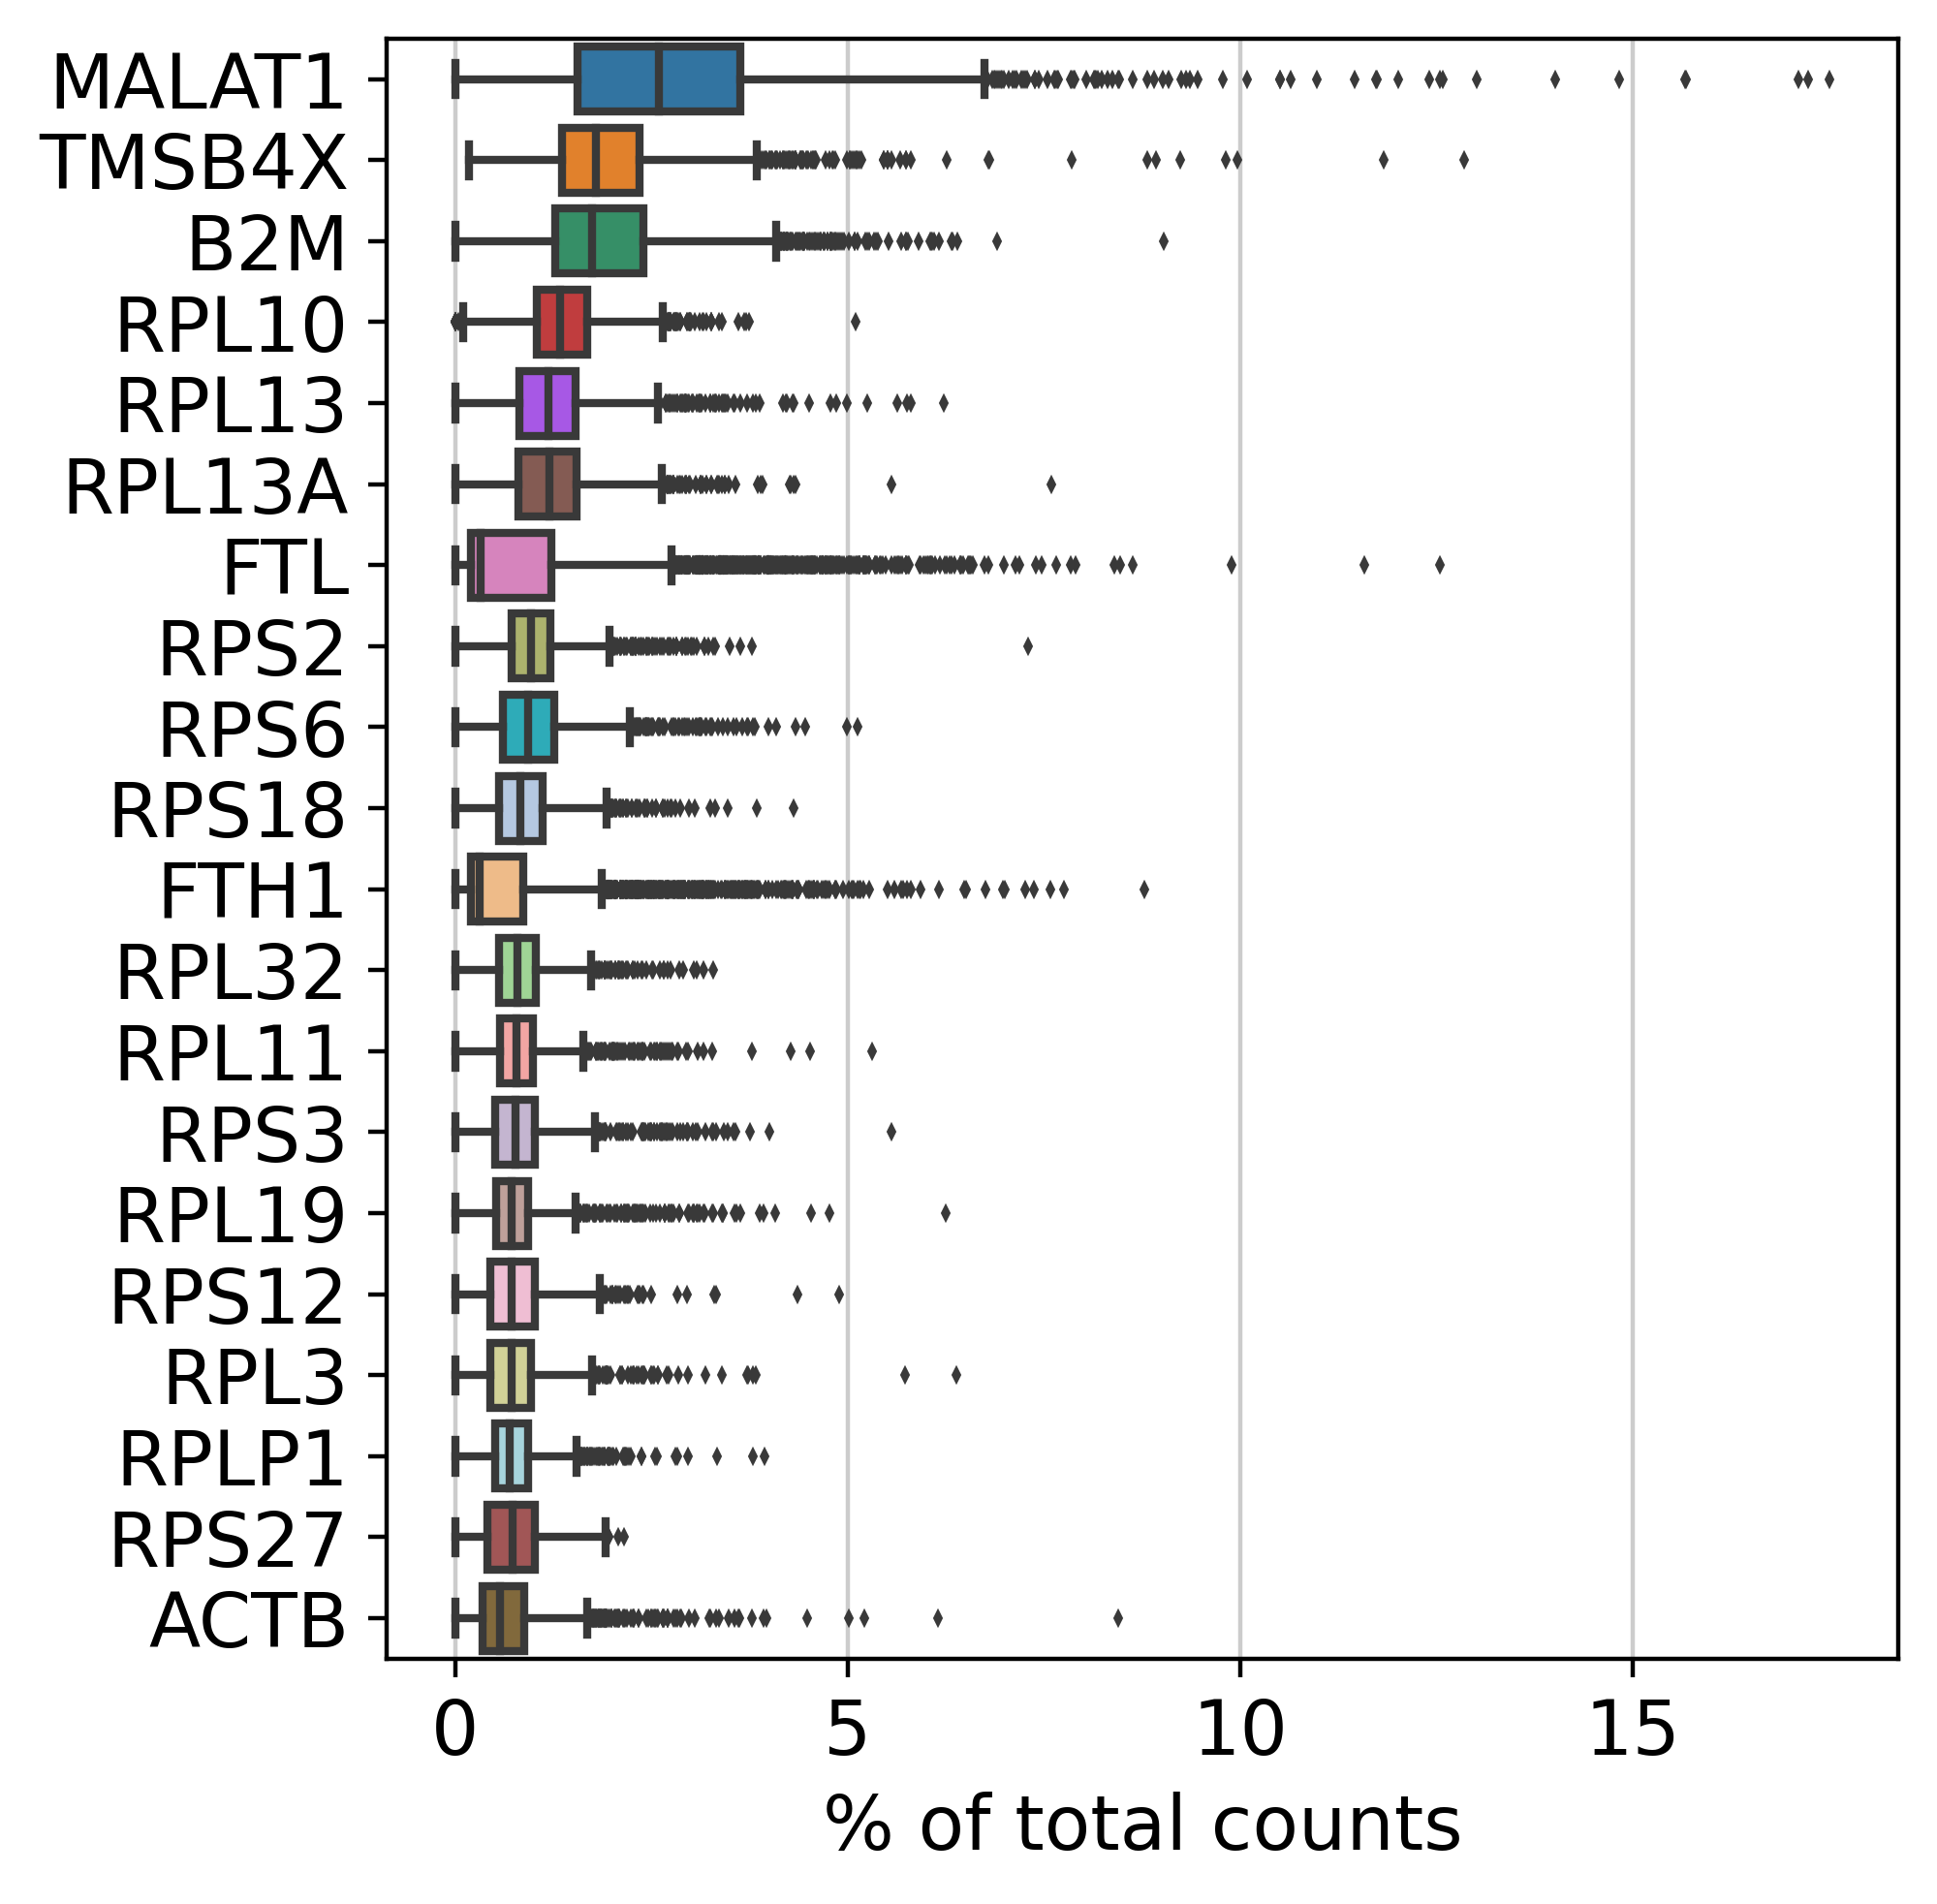

filtered out 19024 genes that are detected in less than 3 cells


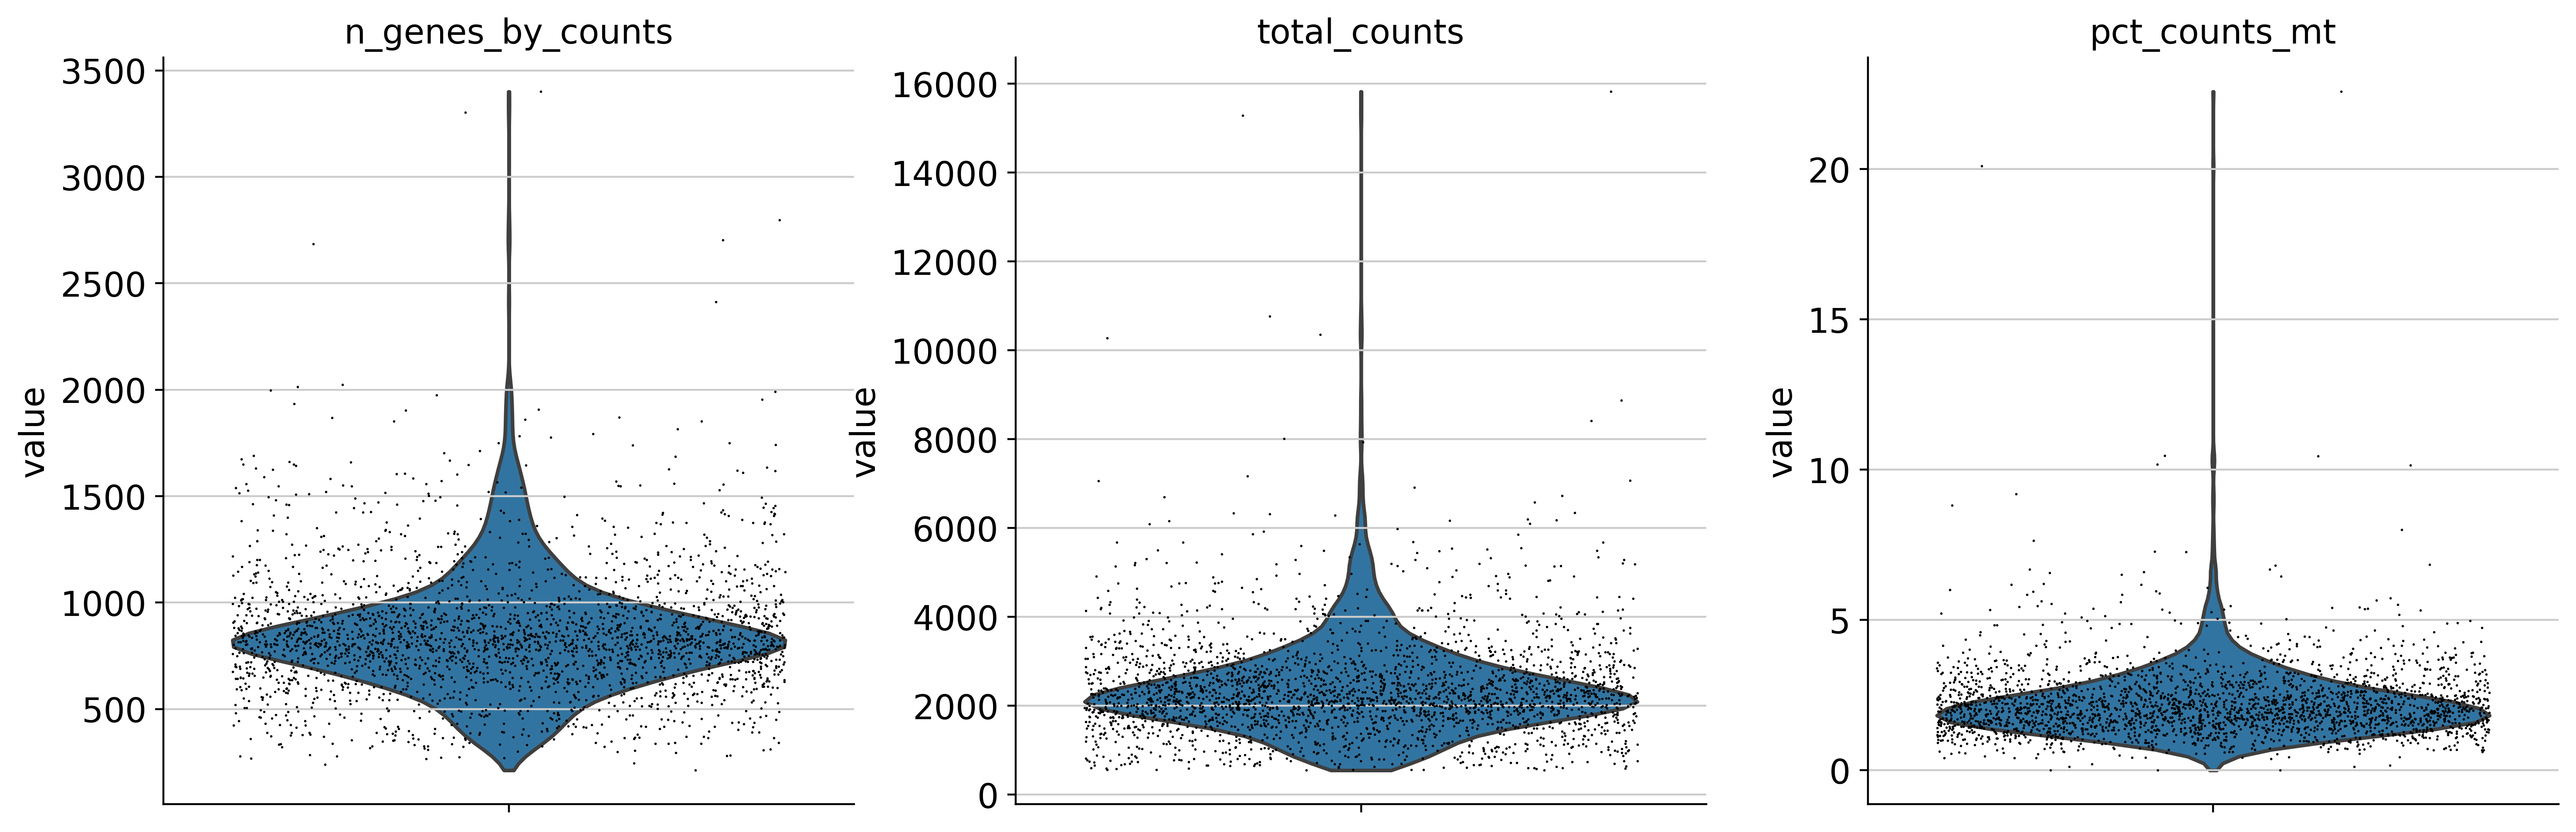

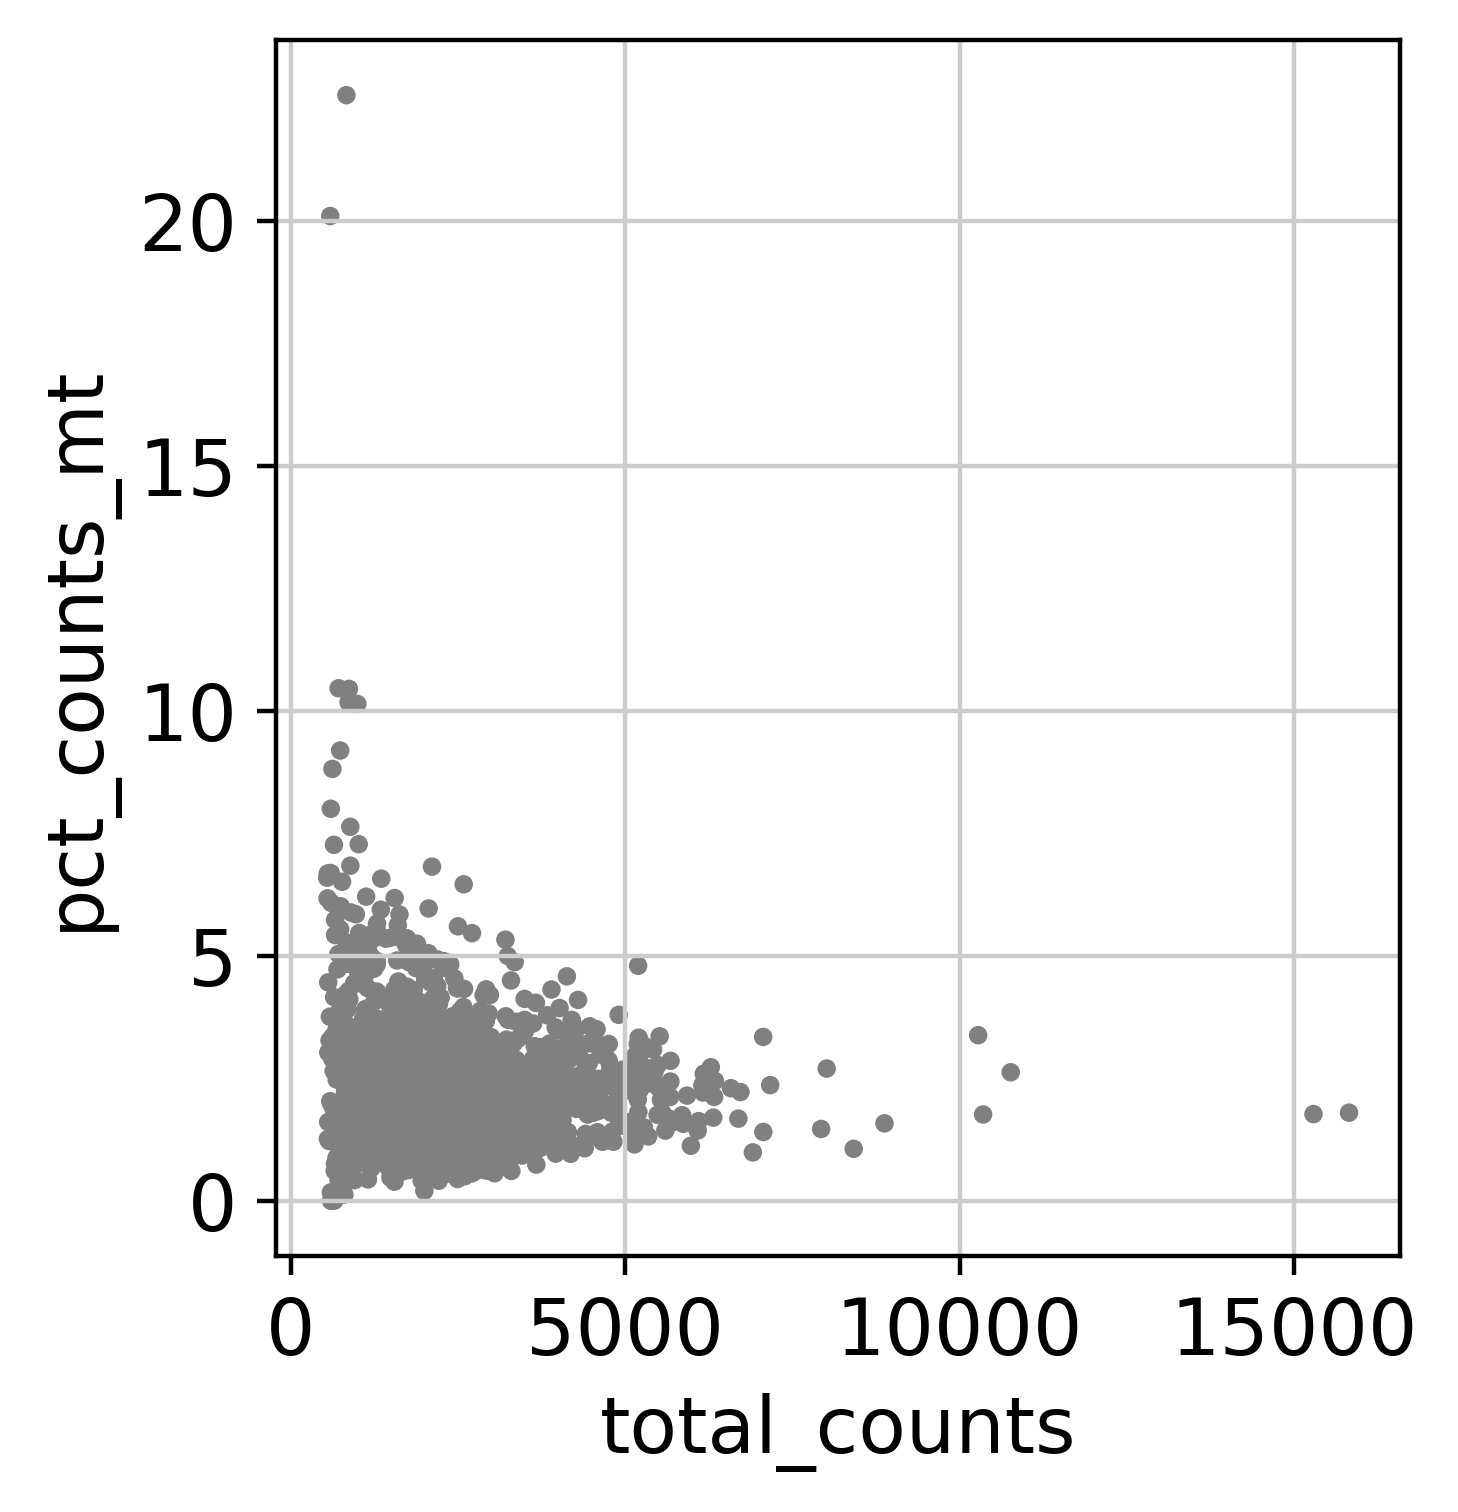

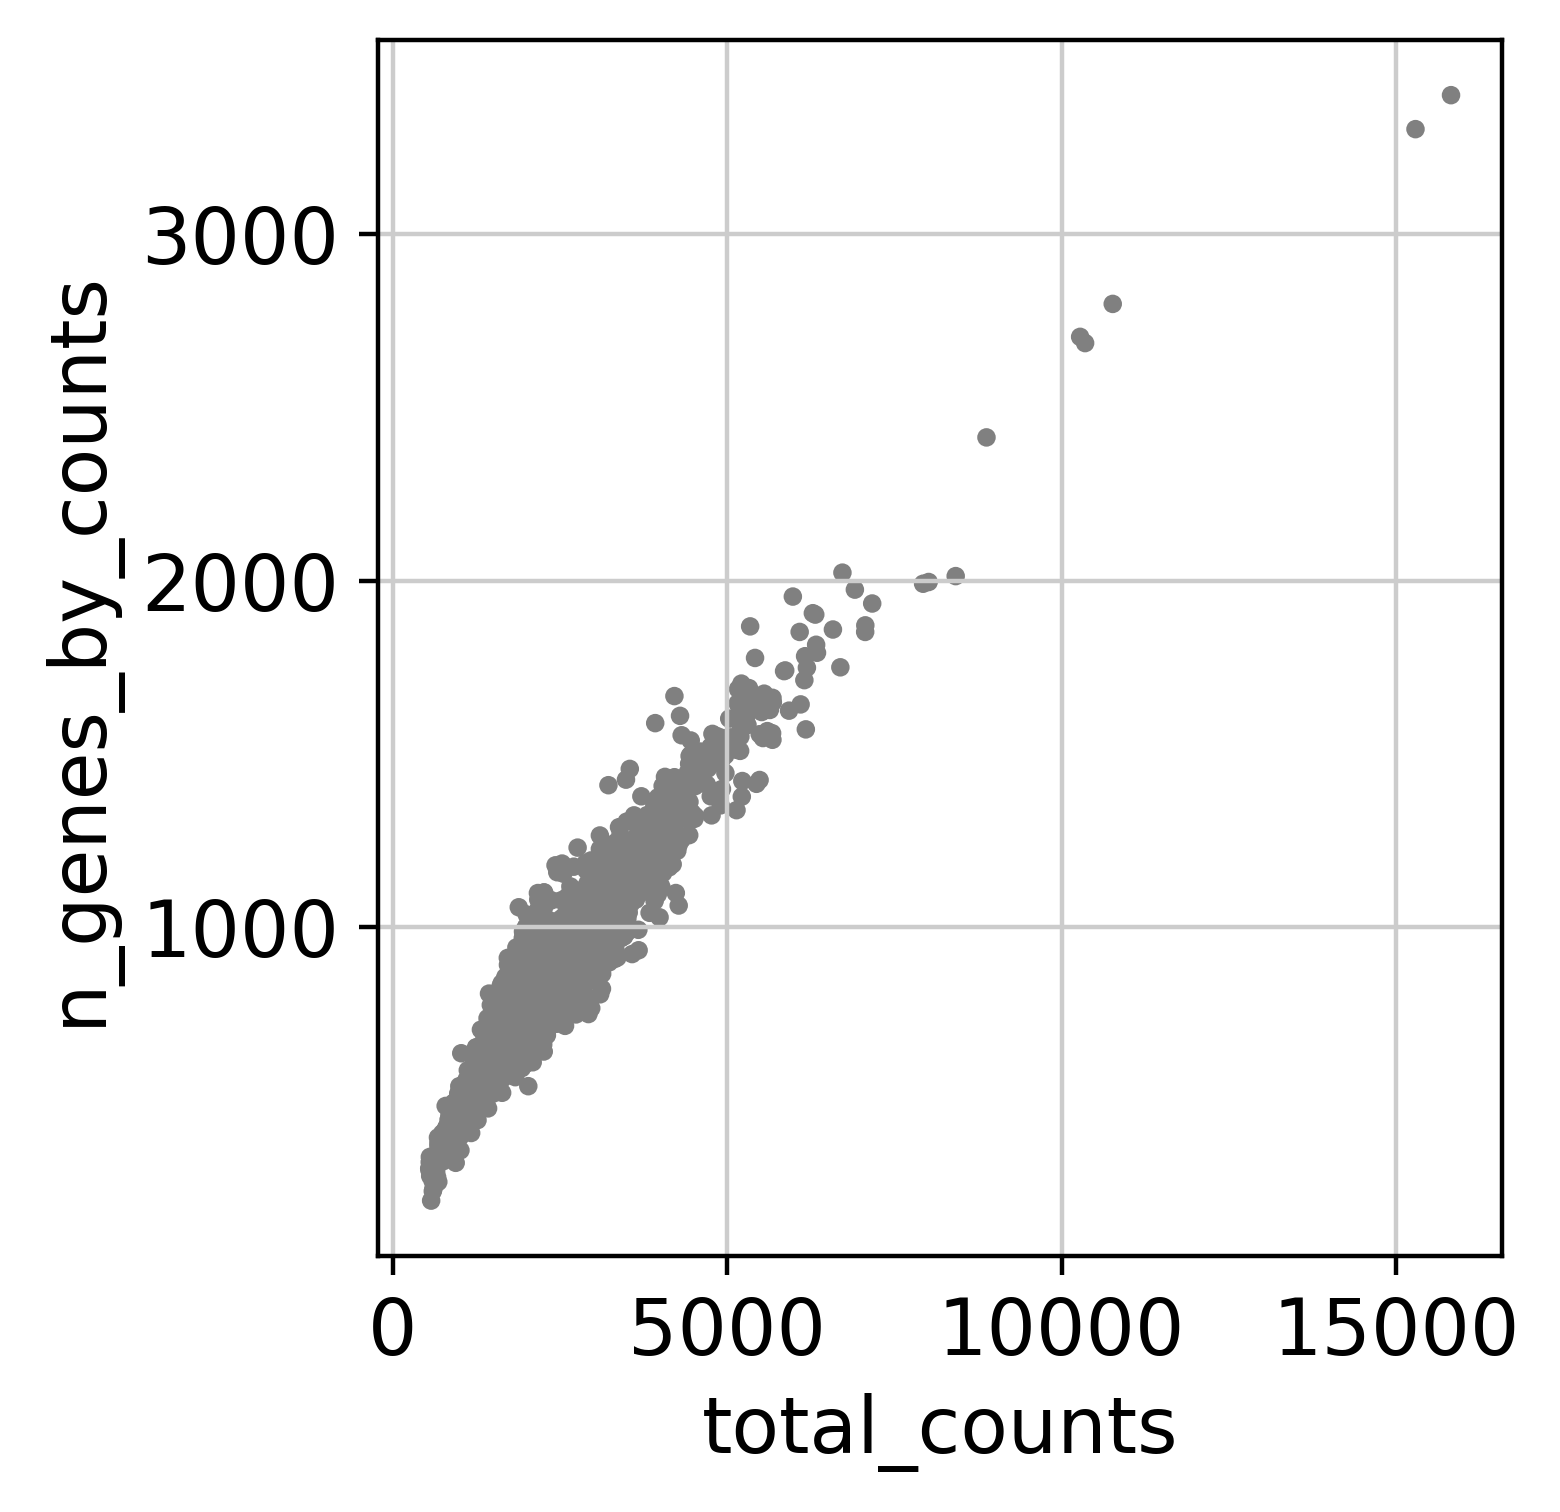

In [6]:
sc.pl.highest_expr_genes(adata, n_top=20, )

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]



#### Normalize and scale

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


/home/ssarnataro/miniconda3/envs/python3.7/lib/python3.7/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [9]:
sc.pp.highly_variable_genes(adata,  min_mean=0.0125, max_mean=3, min_disp=0.5)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


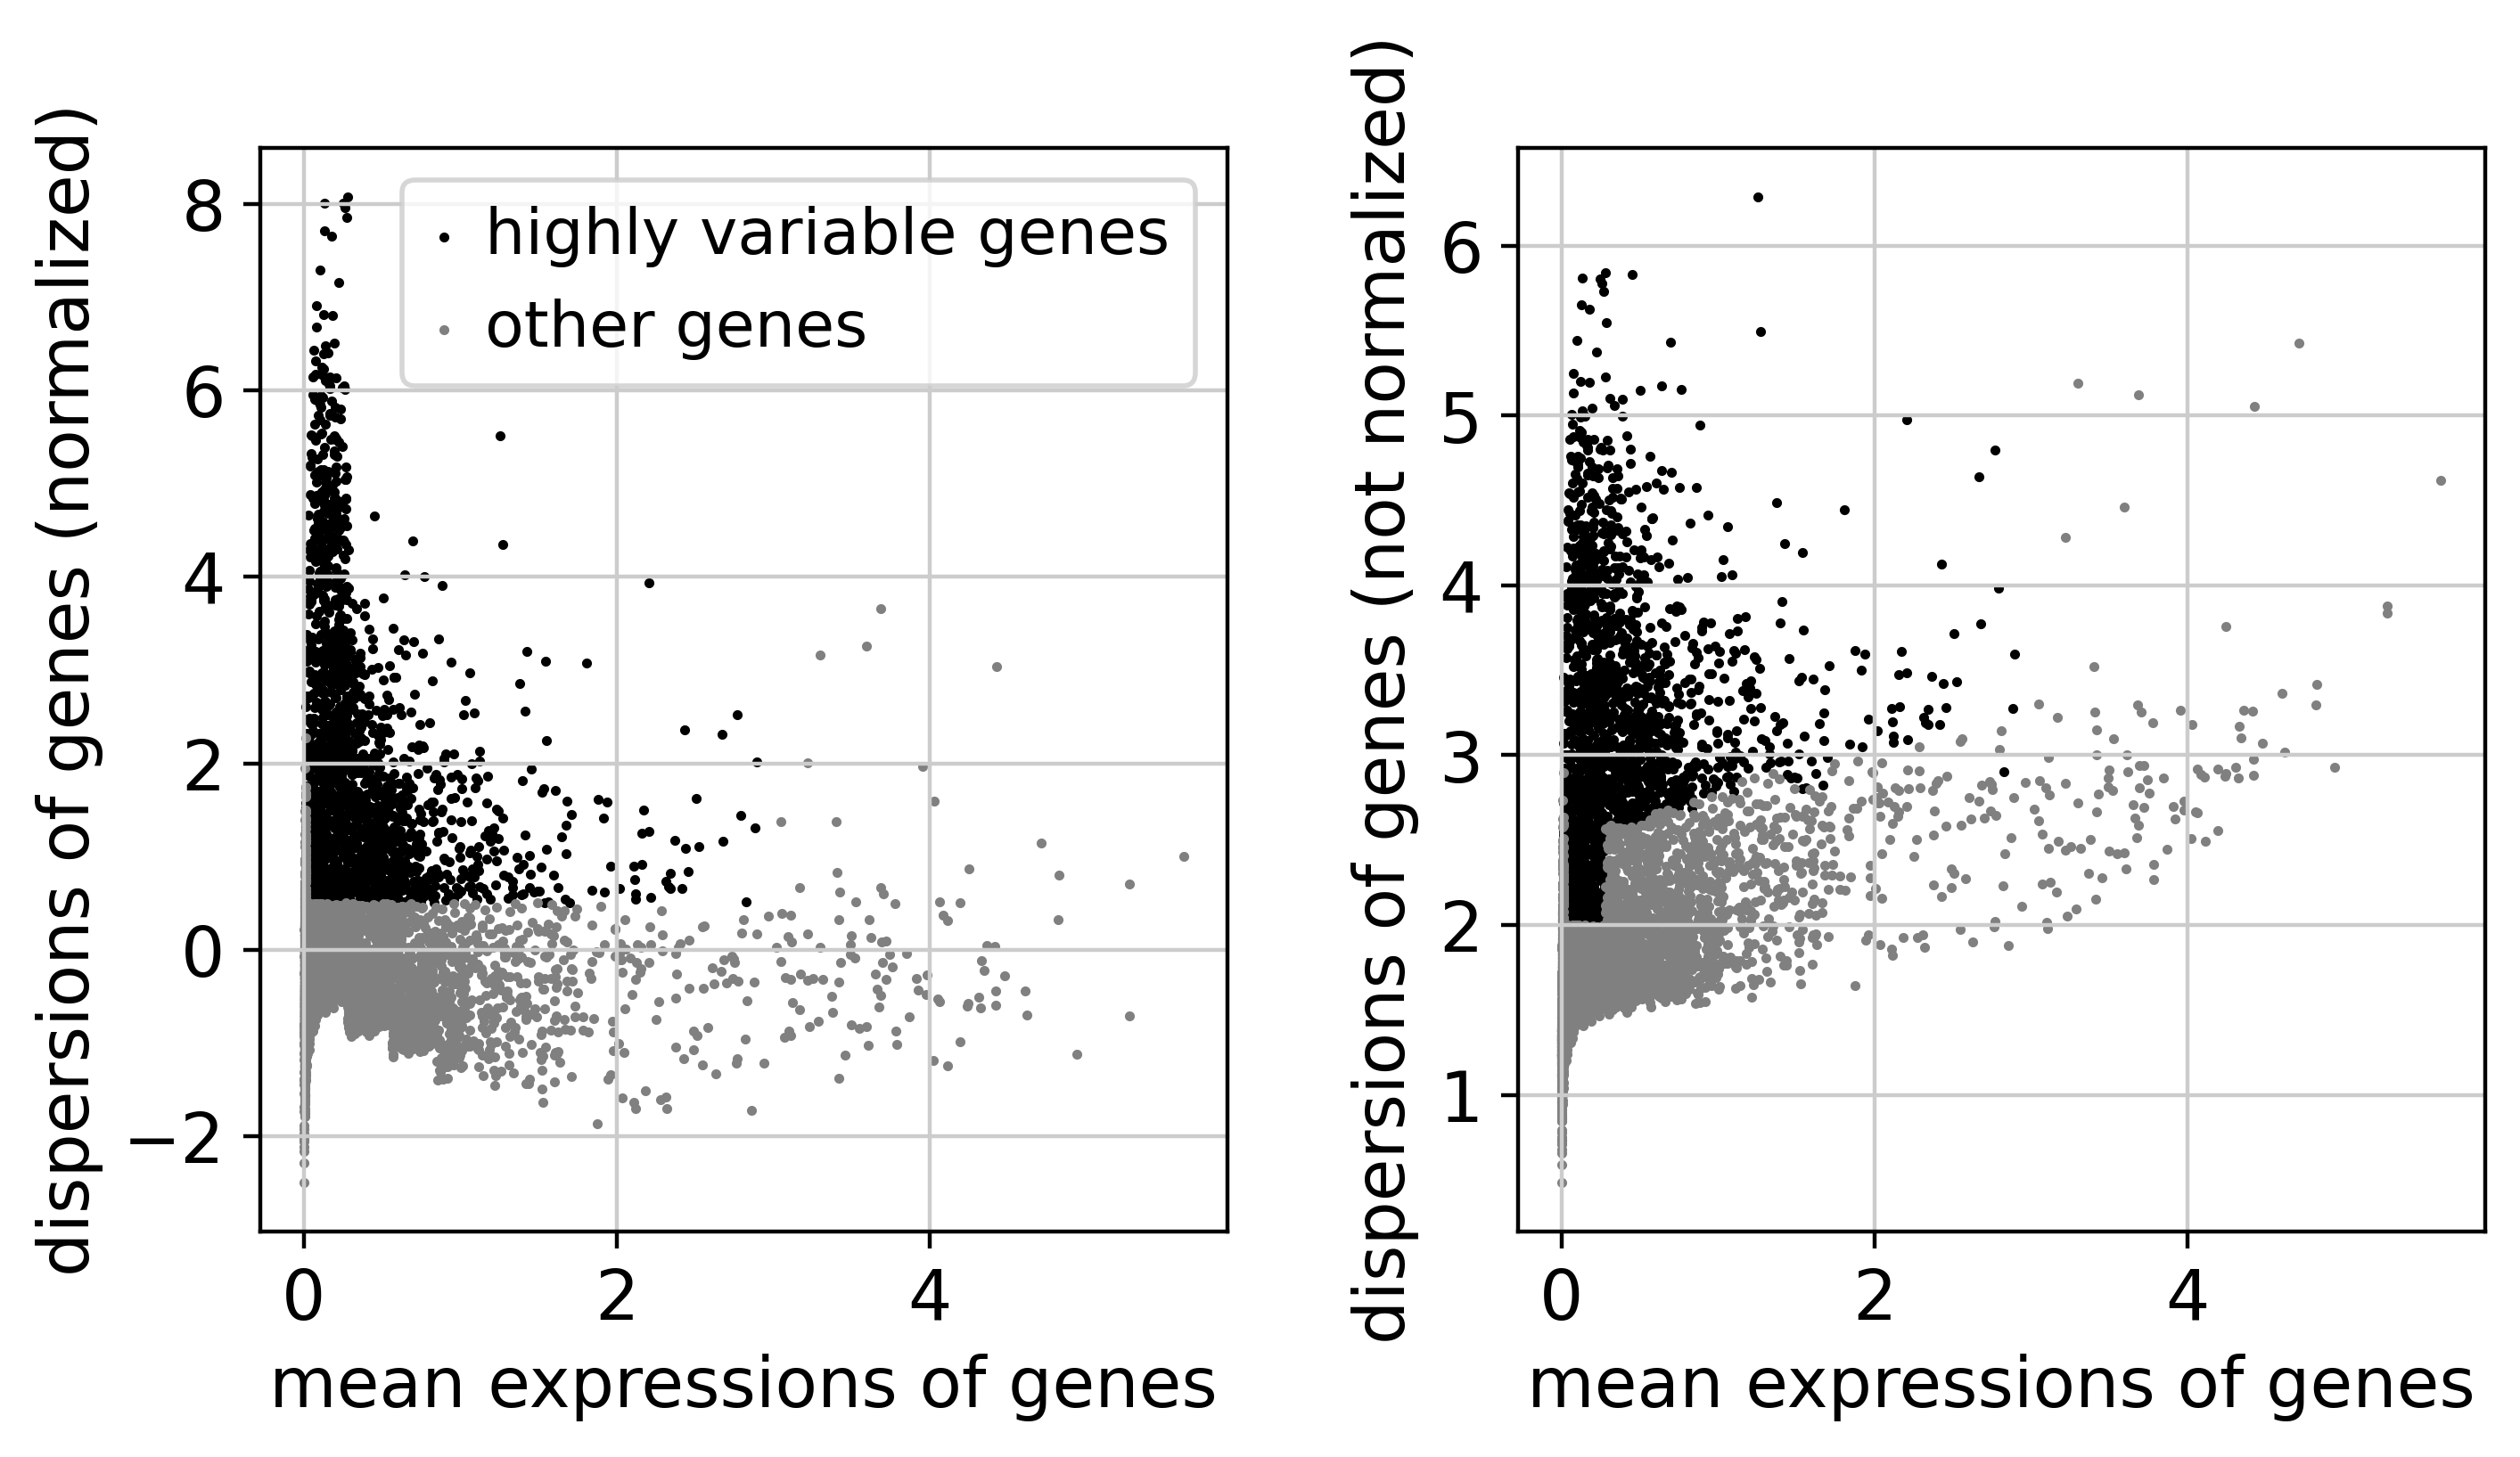

In [10]:
sc.pl.highly_variable_genes(adata)

In [11]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable]

In [12]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:12)


In [13]:
sc.pp.scale(adata, max_value=10)

In [14]:
sc.tl.pca(adata, svd_solver='arpack')


computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)


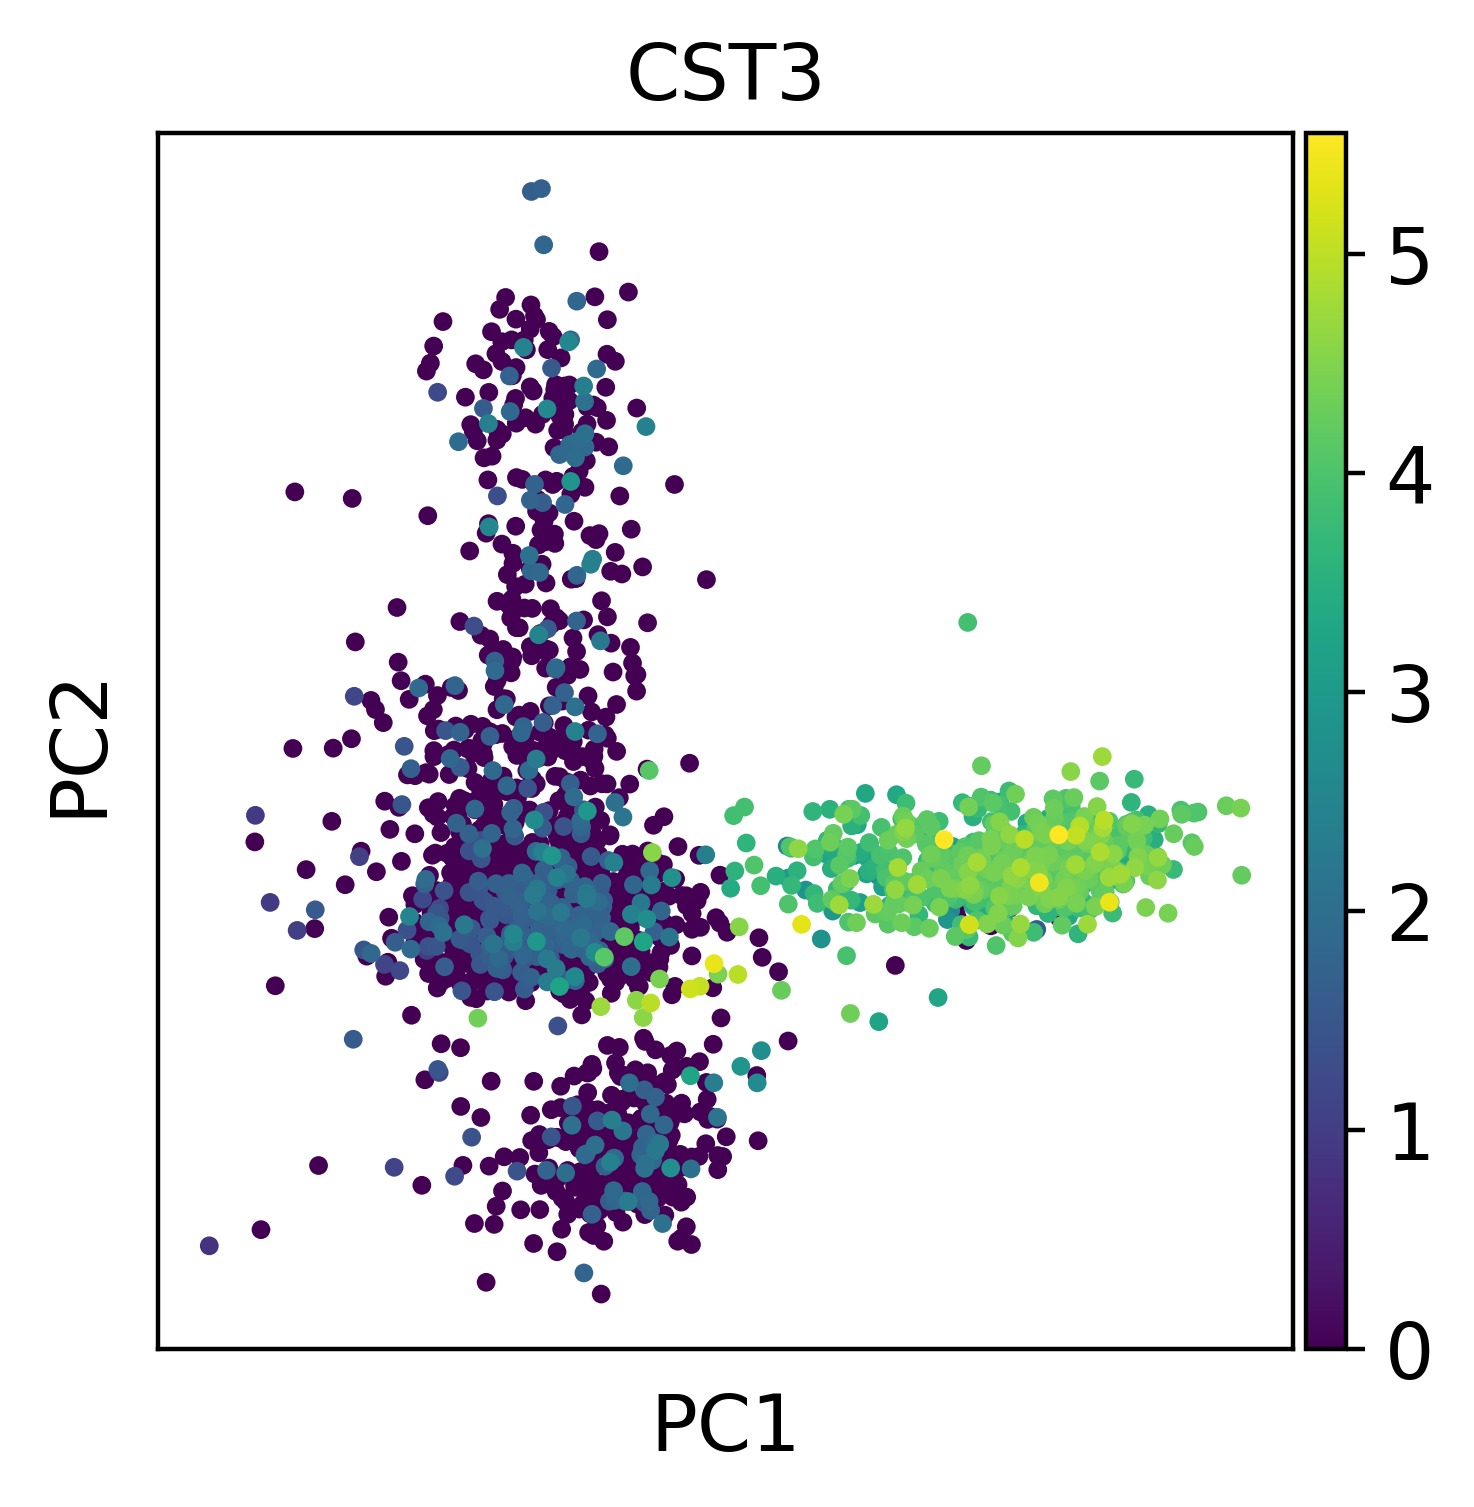

In [15]:
sc.pl.pca(adata, color='CST3')

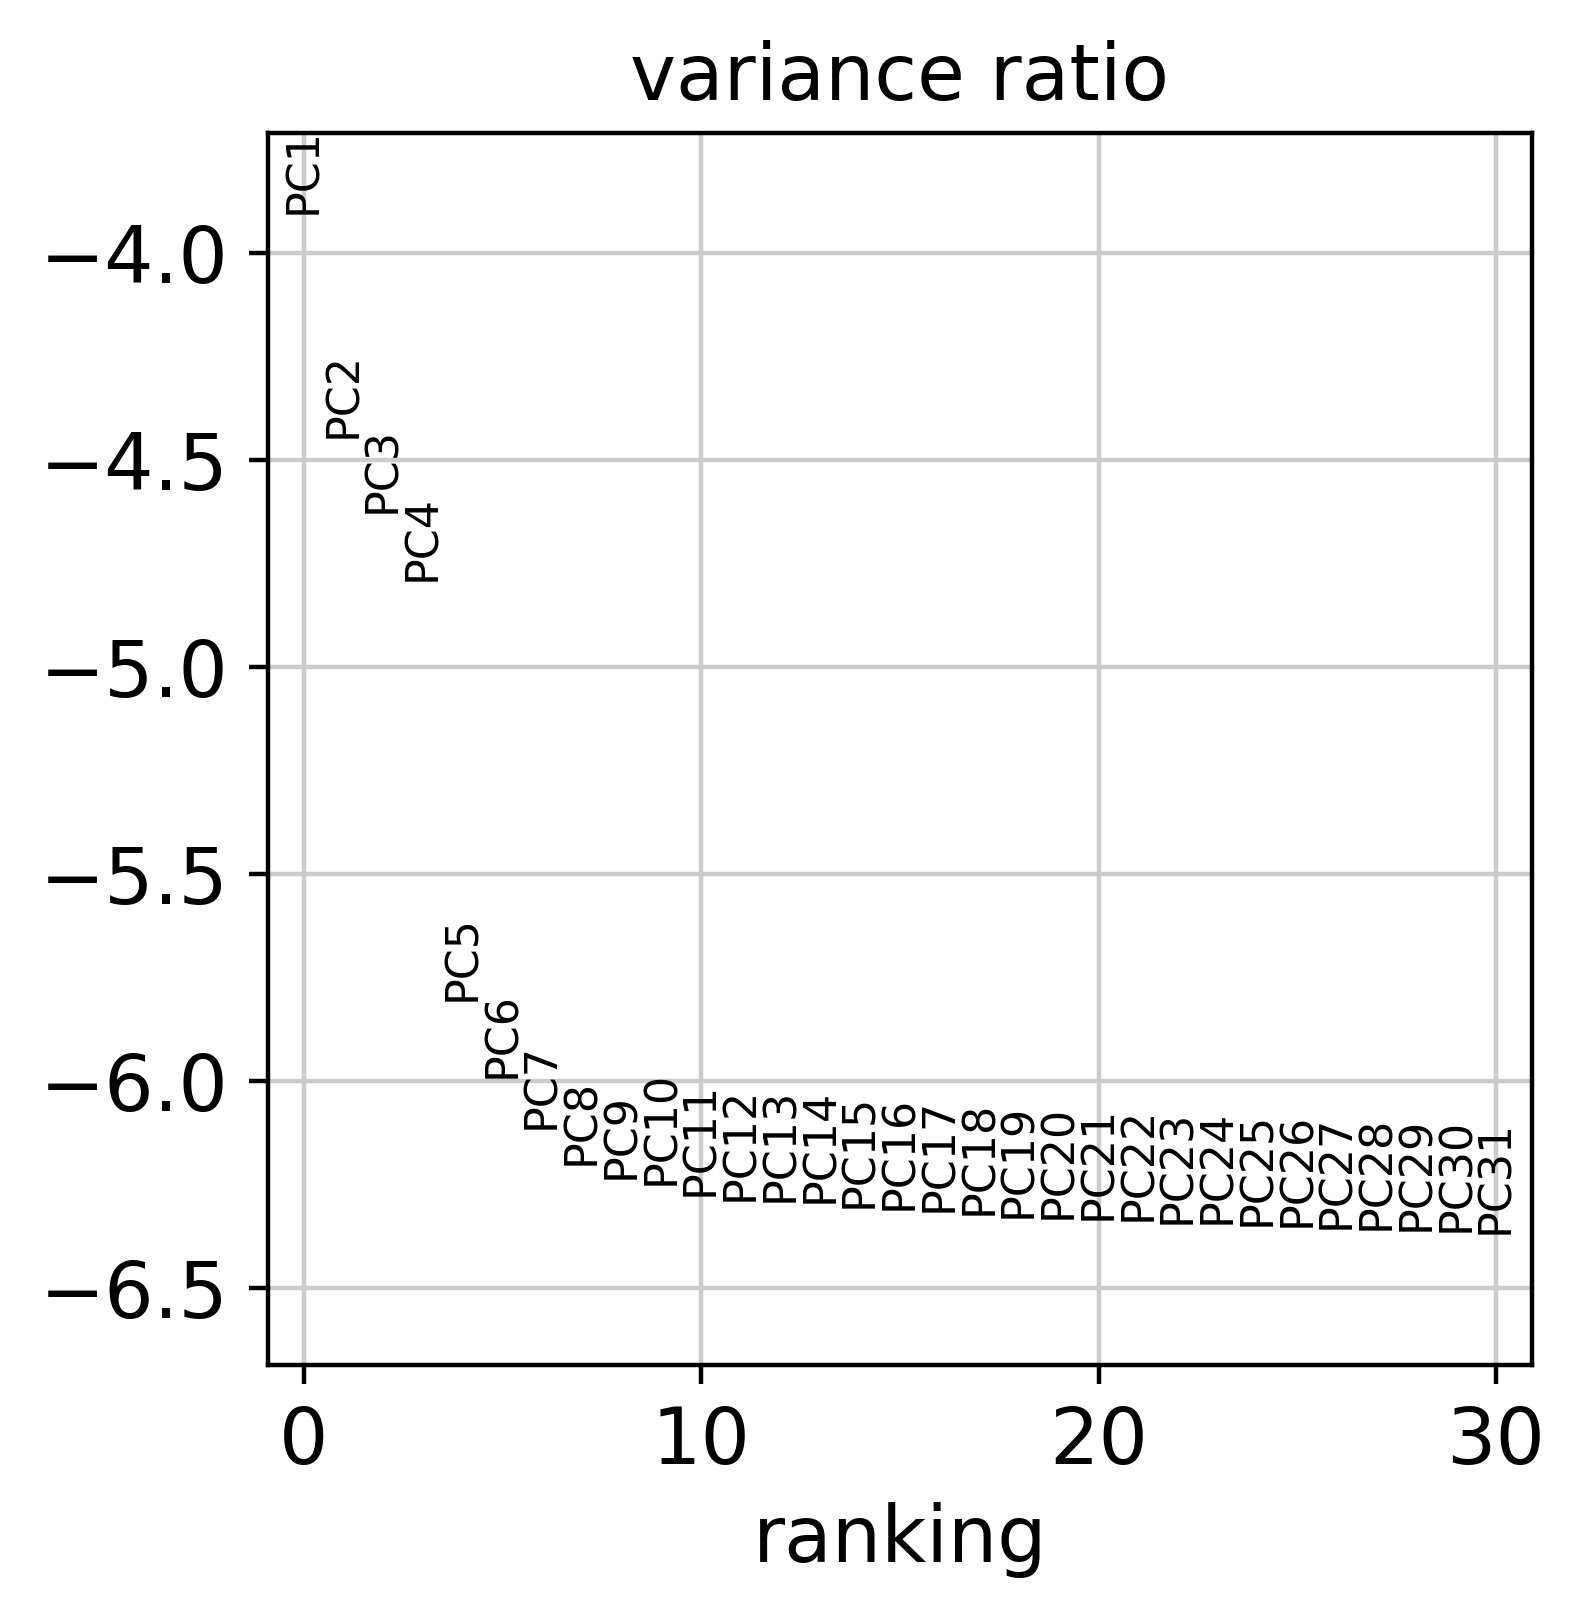

In [16]:
sc.pl.pca_variance_ratio(adata, log=True)

In [17]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40


2023-09-20 09:48:01.065479: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:04)


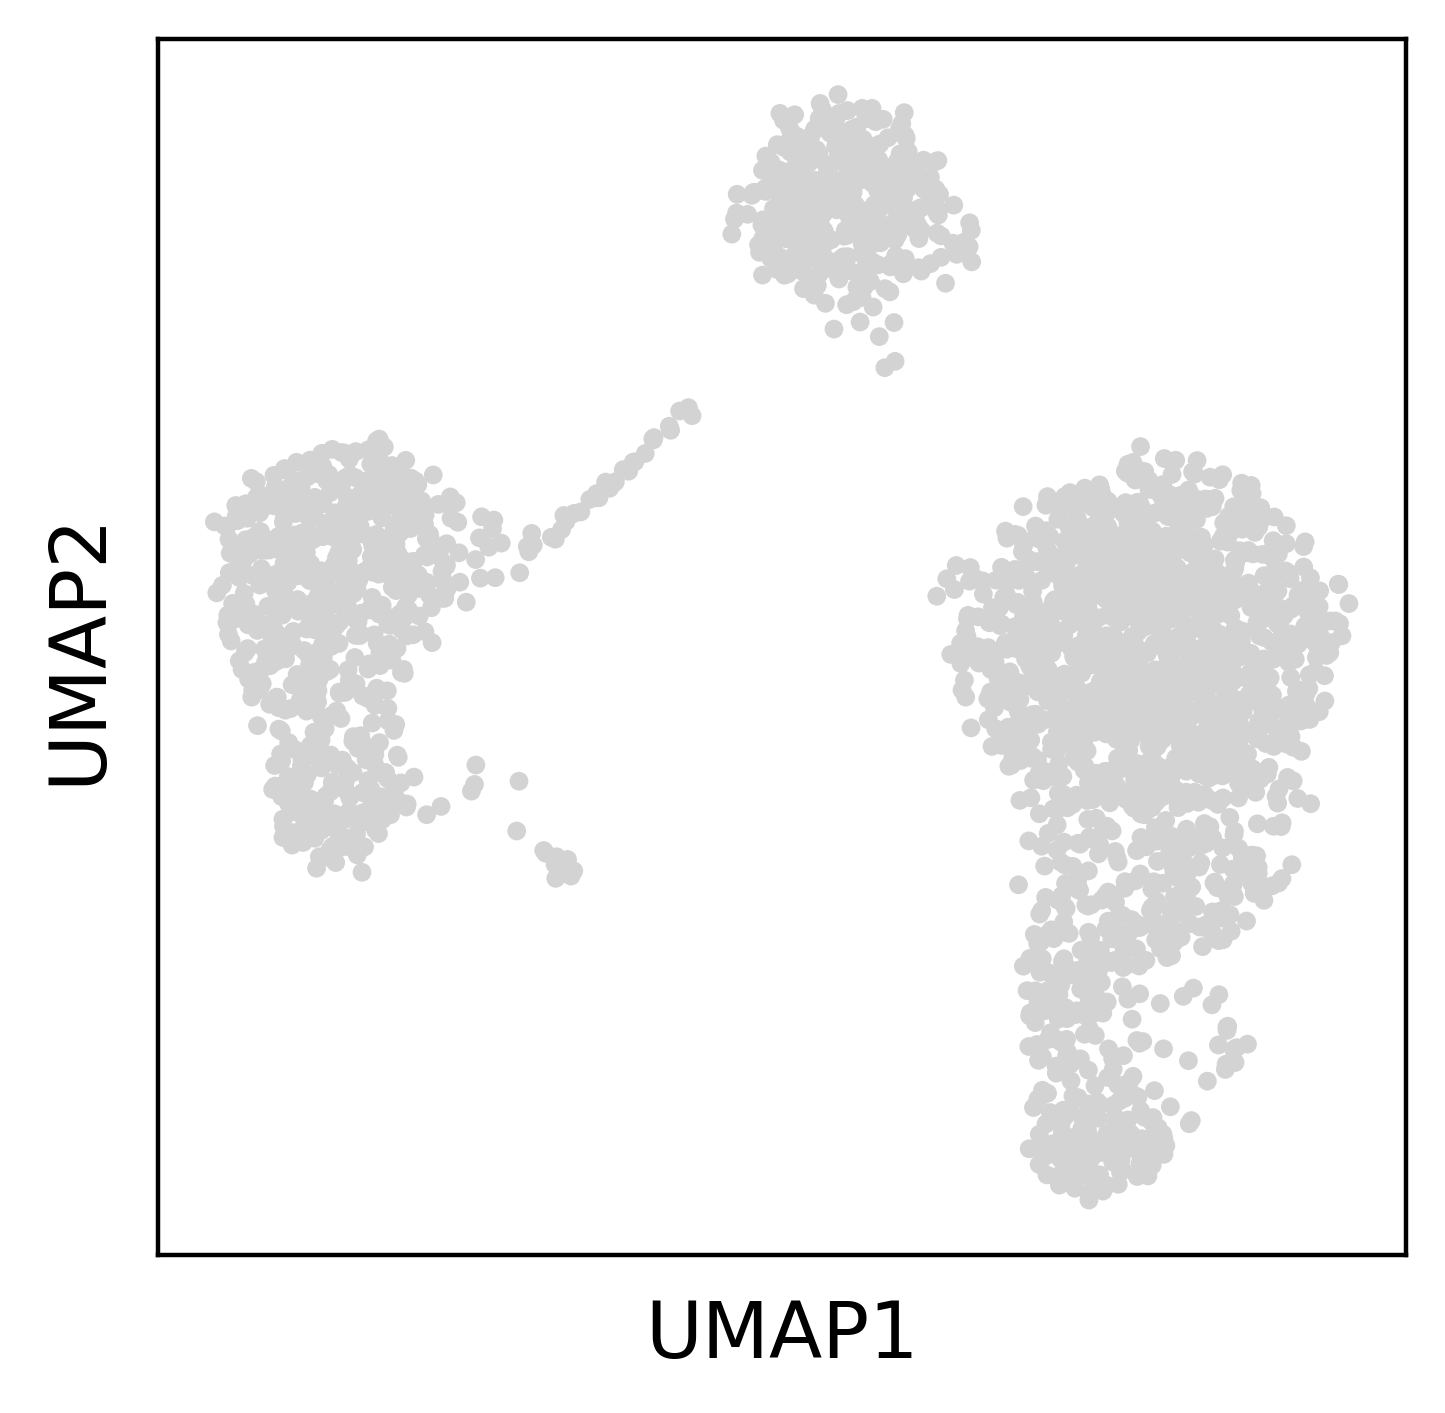

In [18]:
sc.tl.umap(adata)

sc.settings.set_figure_params(dpi = 200, facecolor='white')
sc.pl.umap(adata, use_raw = False)

In [19]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [20]:
results_file = "/home/ssarnataro/Work/3kPBMC_data/processed_data.h5ad"
adata.write(results_file)

In [3]:
adata = sc.read_h5ad("/home/ssarnataro/Work/3kPBMC_data/processed_data.h5ad")

Clustering by using the resolution 0.10, step 1 of 24
Clustering by using the resolution 0.20, step 2 of 24
Clustering by using the resolution 0.30, step 3 of 24
Clustering by using the resolution 0.40, step 4 of 24
Clustering by using the resolution 0.50, step 5 of 24
Clustering by using the resolution 0.60, step 6 of 24
Clustering by using the resolution 0.70, step 7 of 24
Clustering by using the resolution 0.80, step 8 of 24
Clustering by using the resolution 0.90, step 9 of 24
Clustering by using the resolution 1.00, step 10 of 24
Clustering by using the resolution 1.10, step 11 of 24
Clustering by using the resolution 1.20, step 12 of 24
Clustering by using the resolution 1.30, step 13 of 24
Clustering by using the resolution 1.40, step 14 of 24
Clustering by using the resolution 1.50, step 15 of 24
Clustering by using the resolution 1.60, step 16 of 24
Clustering by using the resolution 1.70, step 17 of 24
Clustering by using the resolution 1.80, step 18 of 24
Clustering by using

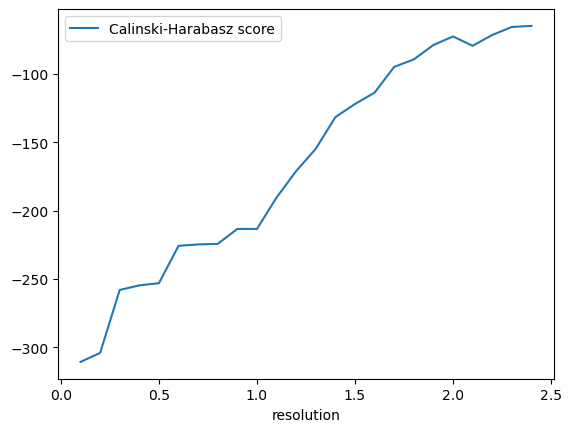

In [5]:
a = clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'pca')

Clustering by using the resolution 0.10, step 1 of 24
Clustering by using the resolution 0.20, step 2 of 24
Clustering by using the resolution 0.30, step 3 of 24
Clustering by using the resolution 0.40, step 4 of 24
Clustering by using the resolution 0.50, step 5 of 24
Clustering by using the resolution 0.60, step 6 of 24
Clustering by using the resolution 0.70, step 7 of 24
Clustering by using the resolution 0.80, step 8 of 24
Clustering by using the resolution 0.90, step 9 of 24
Clustering by using the resolution 1.00, step 10 of 24
Clustering by using the resolution 1.10, step 11 of 24
Clustering by using the resolution 1.20, step 12 of 24
Clustering by using the resolution 1.30, step 13 of 24
Clustering by using the resolution 1.40, step 14 of 24
Clustering by using the resolution 1.50, step 15 of 24
Clustering by using the resolution 1.60, step 16 of 24
Clustering by using the resolution 1.70, step 17 of 24
Clustering by using the resolution 1.80, step 18 of 24
Clustering by using

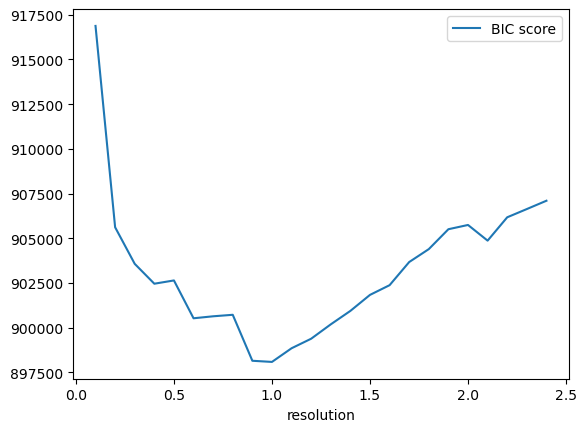

In [4]:
a = clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.5,step=0.1, plot=True, dim_reduction = 'pca')

In [23]:
 sc.tl.leiden(adata, key_added="leiden_1.0", resolution=1.0)

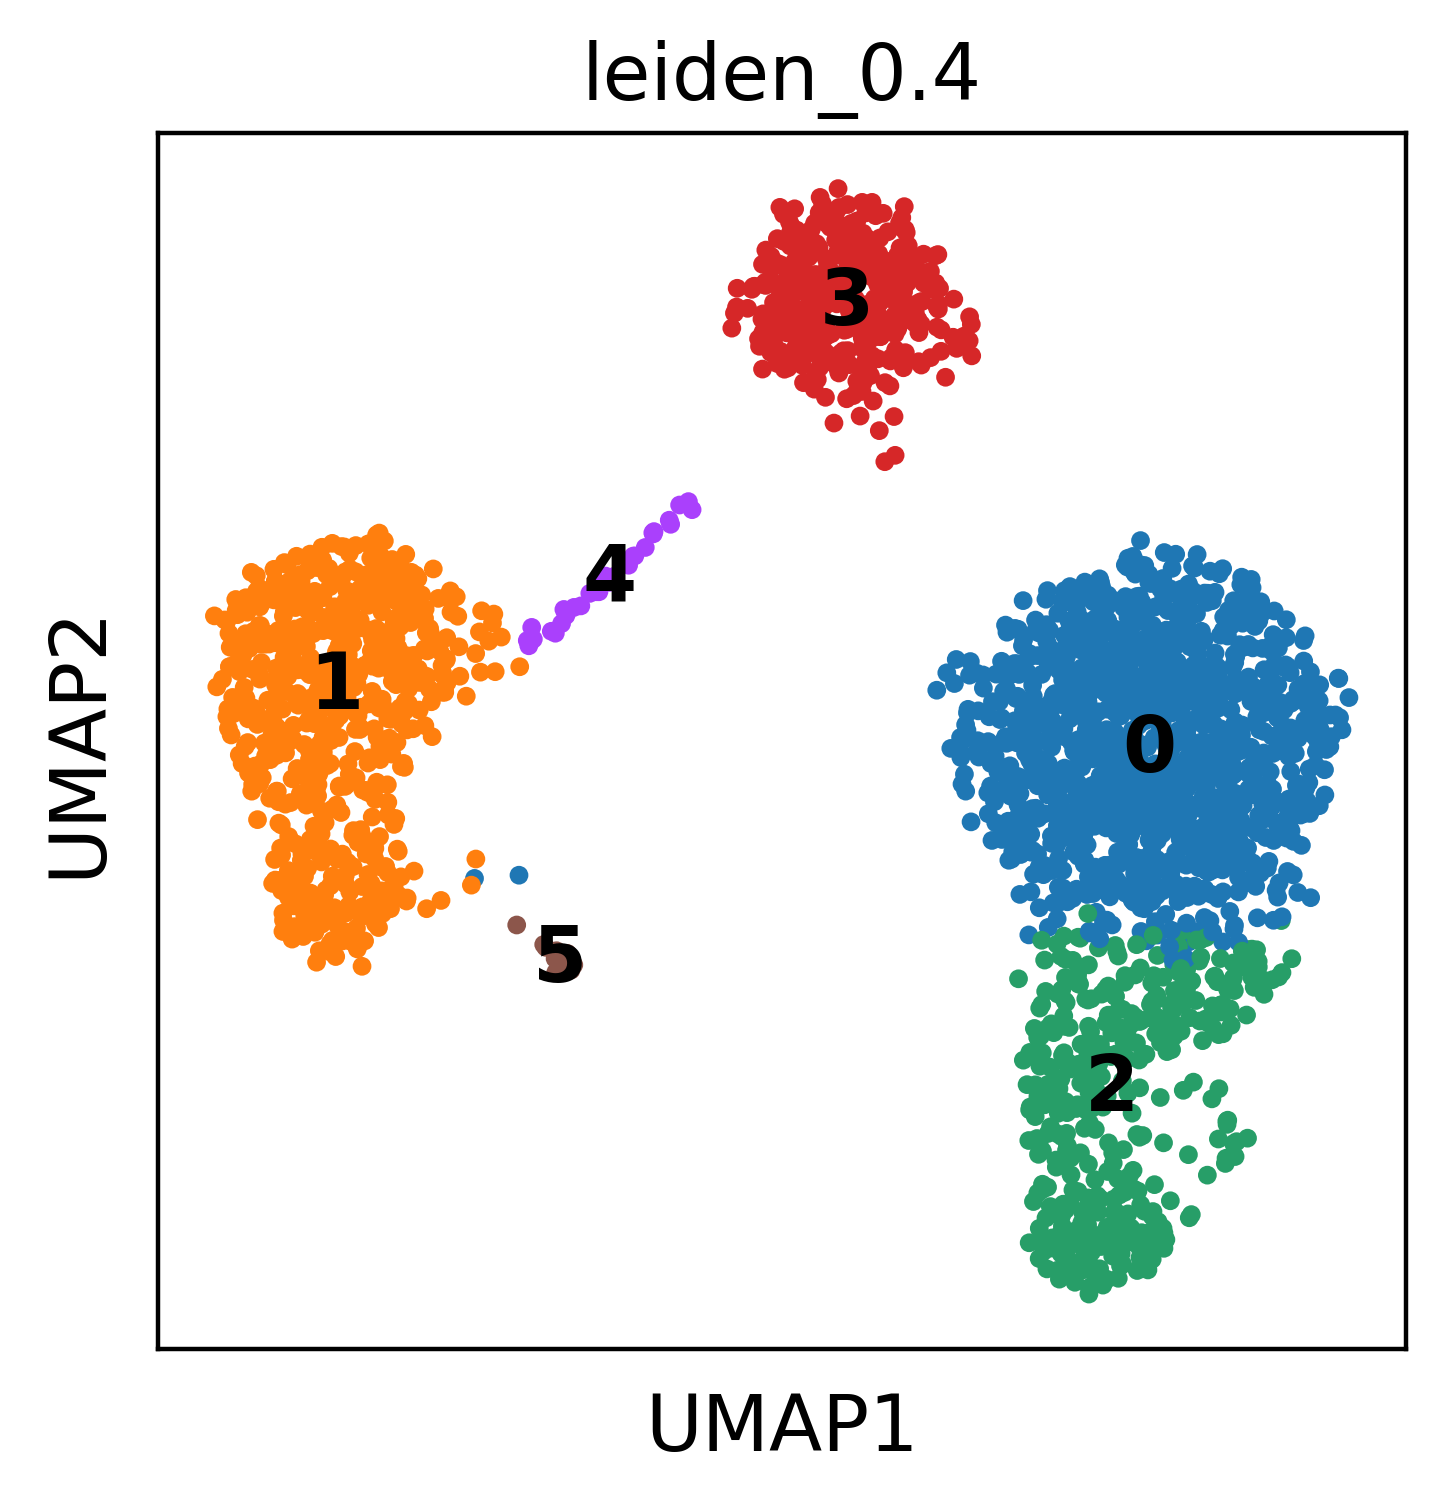

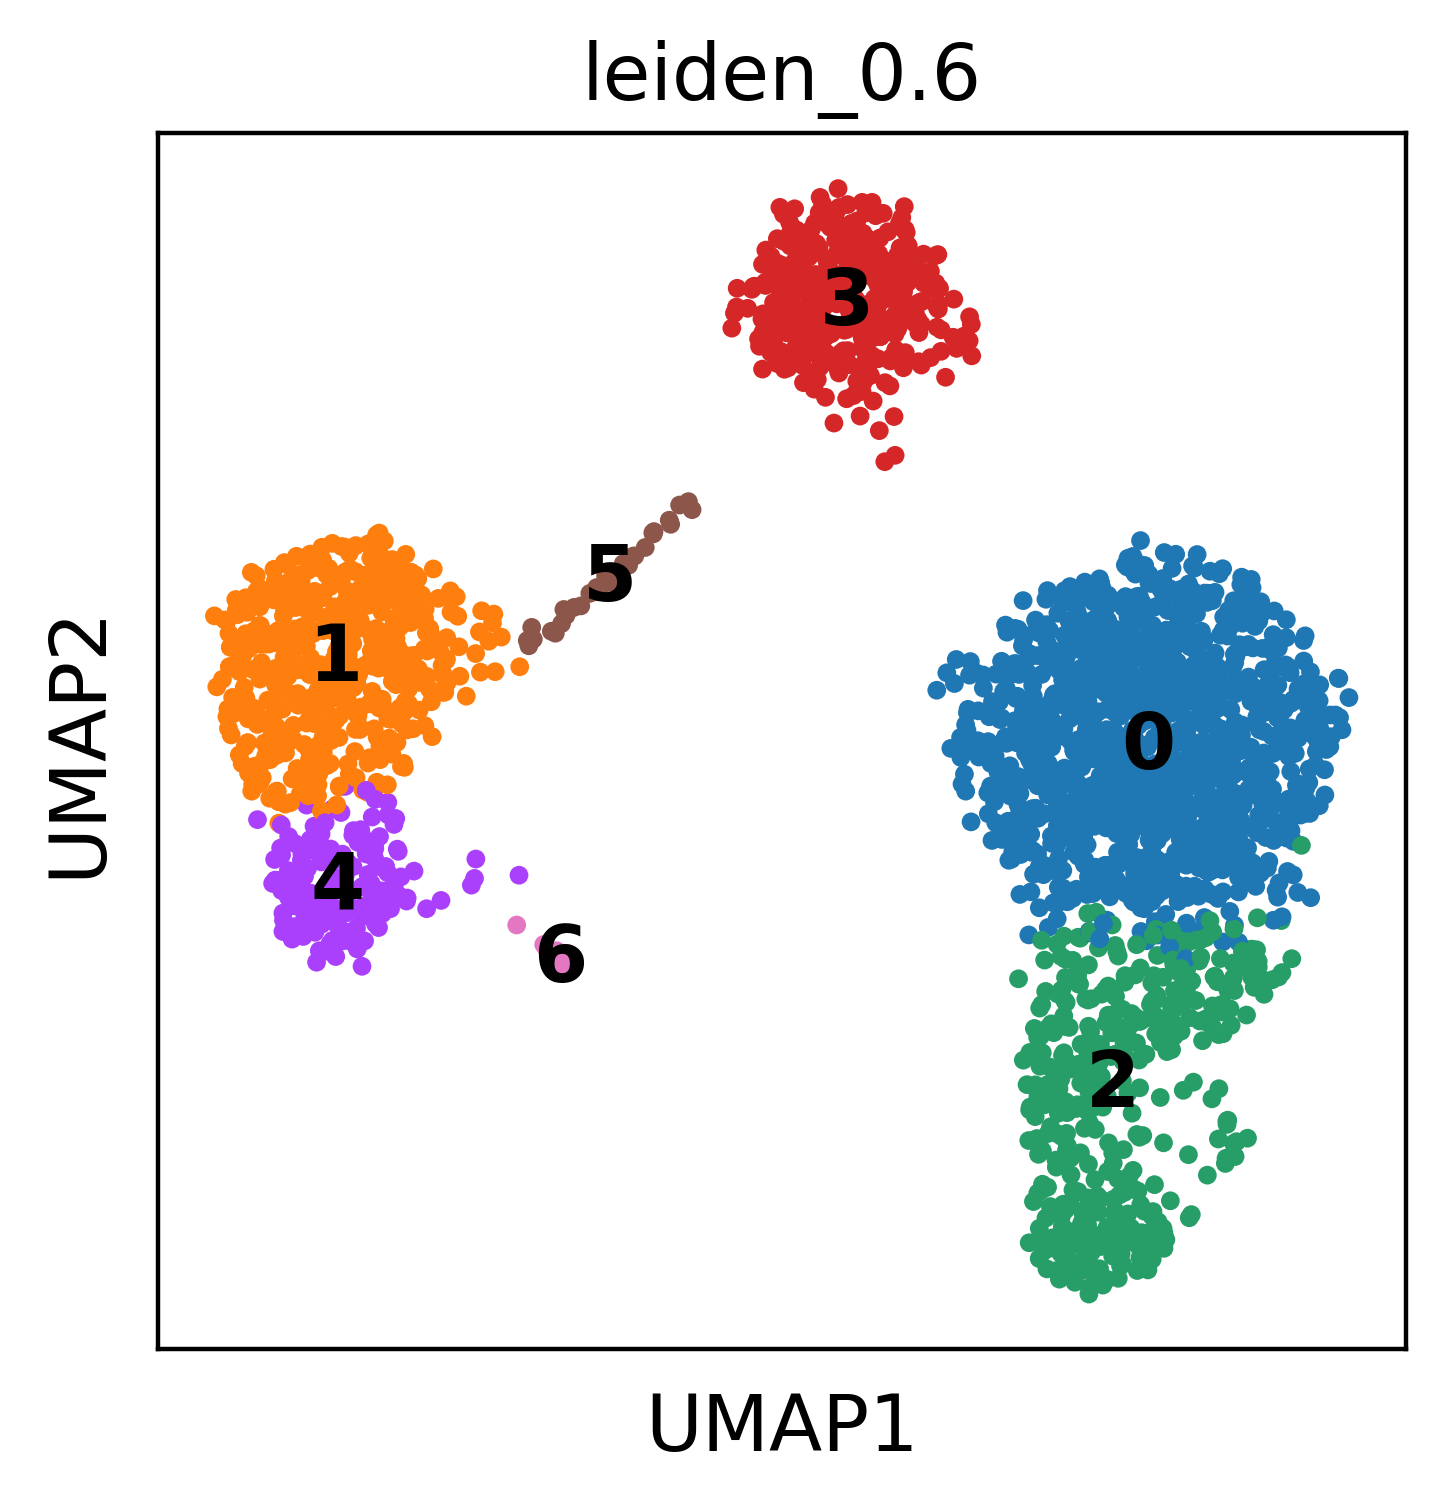

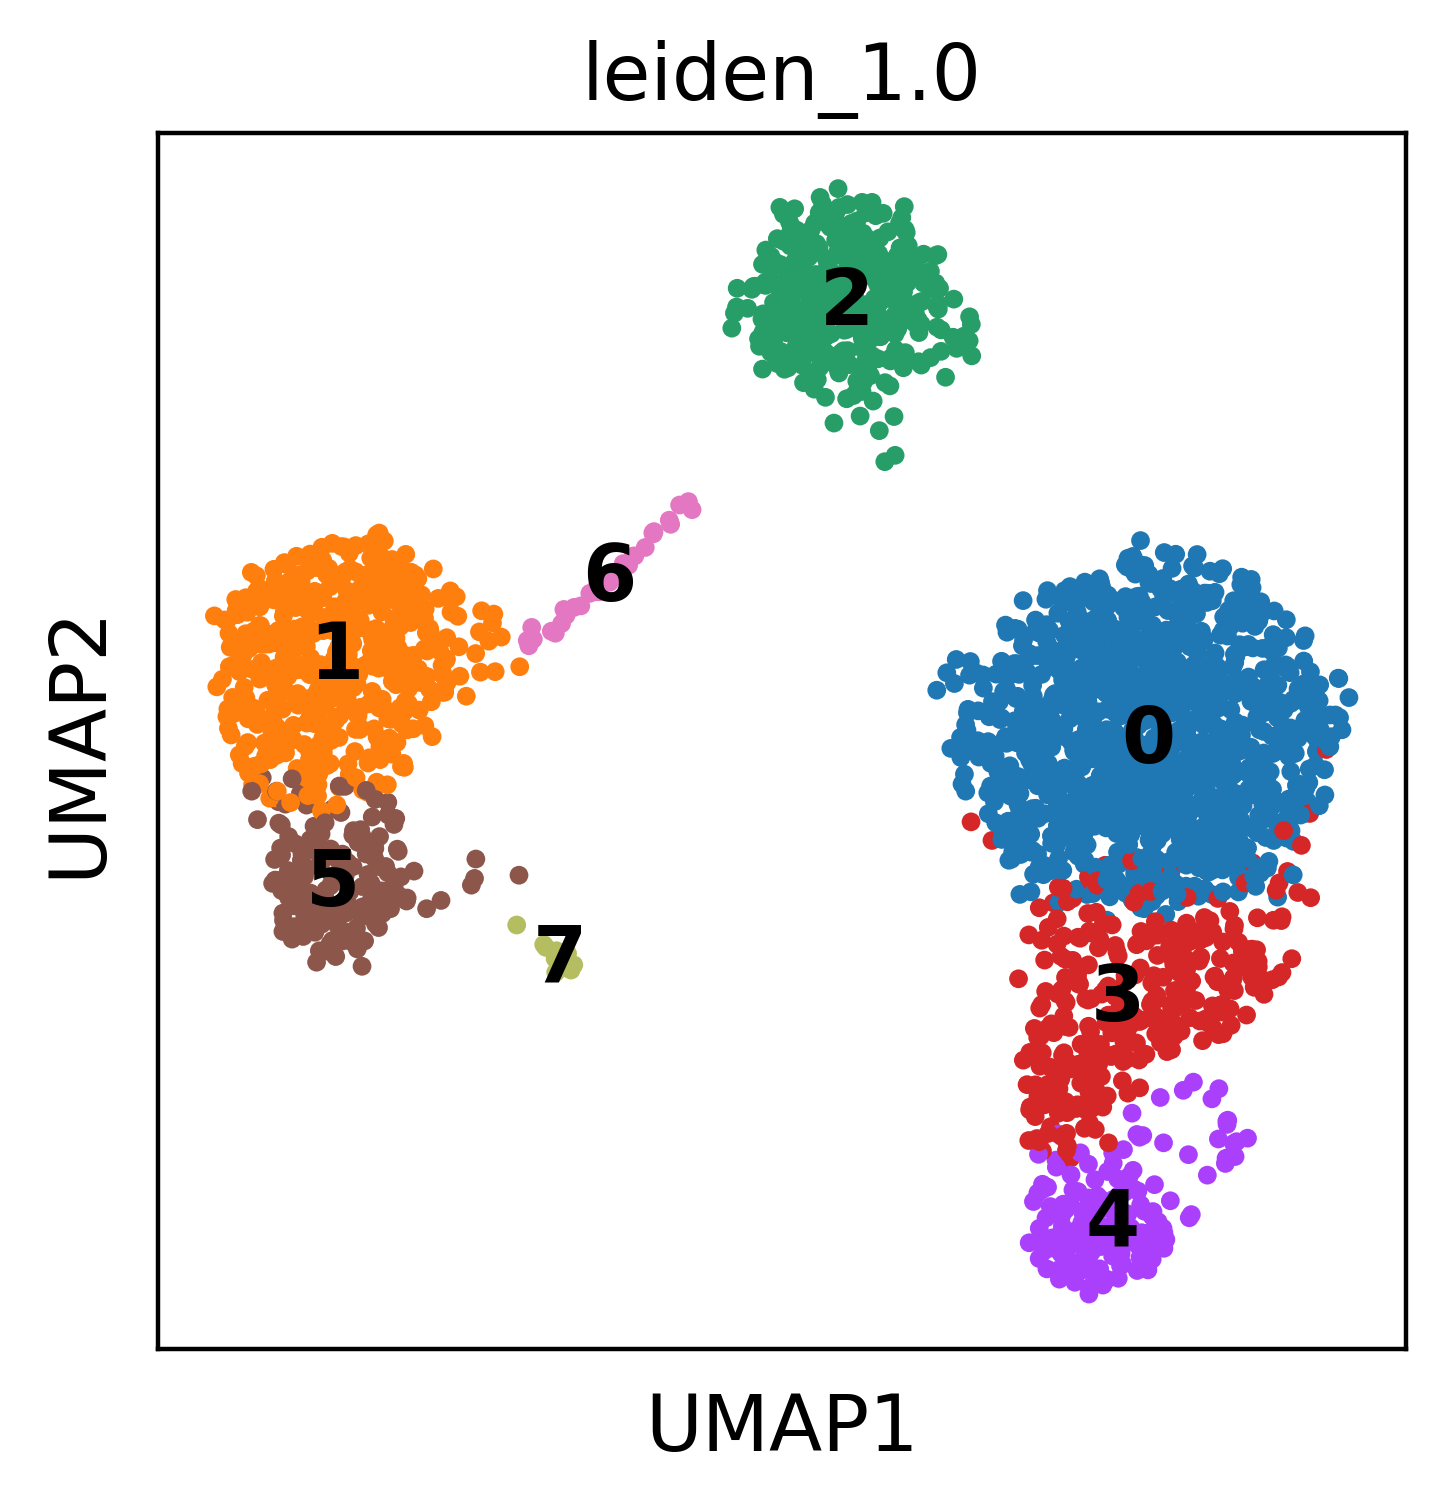

In [29]:
for res in [0.4, 0.6,1.0]:
    sc.tl.leiden(adata, key_added="leiden_%s" %res, resolution=res)
    sc.pl.umap(adata, color="leiden_%s" %res,legend_loc="on data")

In [23]:
adata.obsm['X_pca'].shape[1]

50